In [1]:
# Importacion de librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# Corpus de entrenamiento

corpus = [
    "la inteligencia artificial aprende patrones en los datos",
    "la inteligencia artificial procesa secuencias de texto",
    "la inteligencia artificial puede generar lenguaje",
    "la inteligencia artificial necesita contexto para predecir",
    "la inteligencia artificial usa modelos probabilisticos",

    "las redes recurrentes procesan informacion paso a paso",
    "las redes recurrentes mantienen un estado oculto",
    "las redes recurrentes modelan secuencias temporales",
    "las redes recurrentes pueden sufrir amnesia contextual",
    "las redes recurrentes comprimen el pasado en un vector",

    "las gru simplifican la memoria recurrente",
    "las gru usan compuertas de actualizacion",
    "las gru usan compuertas de reinicio",
    "las gru mezclan informacion pasada y nueva",
    "las gru son mas ligeras que las lstm",

    "las lstm usan compuertas para controlar memoria",
    "las lstm conservan informacion importante",
    "las lstm reducen el gradiente desvaneciente",
    "las lstm separan estado oculto y estado de celda",
    "las lstm ayudan en secuencias largas",

    "un modelo de lenguaje predice la siguiente palabra",
    "un modelo de lenguaje aprende probabilidades condicionales",
    "un modelo de lenguaje usa softmax para elegir tokens",
    "un modelo de lenguaje genera texto paso a paso",
    "un modelo de lenguaje depende del contexto previo",

    "la softmax convierte logits en probabilidades",
    "la softmax distribuye probabilidad sobre el vocabulario",
    "la softmax permite seleccionar el siguiente token",
    "la softmax se usa en clasificacion multiclase",
    "la softmax produce una distribucion normalizada",

    "la entropia cruzada mide la sorpresa del modelo",
    "la entropia cruzada penaliza predicciones incorrectas",
    "la entropia cruzada disminuye durante el entrenamiento",
    "la entropia cruzada se relaciona con la perplejidad",
    "la entropia cruzada evalua la palabra correcta",

    "la perplejidad mide incertidumbre del modelo",
    "la perplejidad baja indica mejor prediccion",
    "la perplejidad alta indica mucha confusion",
    "la perplejidad se interpreta como opciones efectivas",
    "la perplejidad depende del vocabulario",

    "la temperatura controla la creatividad del muestreo",
    "la temperatura baja produce texto conservador",
    "la temperatura alta produce texto diverso",
    "la temperatura modifica la distribucion de probabilidad",
    "la temperatura no cambia los pesos del modelo",

    "top k limita las palabras candidatas",
    "top k conserva las palabras mas probables",
    "top k reduce opciones poco coherentes",
    "top p usa probabilidad acumulada",
    "top p adapta el numero de candidatos",

    "beam search conserva multiples hipotesis",
    "beam search explora varias rutas posibles",
    "beam search poda las secuencias menos probables",
    "beam search busca una secuencia globalmente mejor",
    "beam search aumenta el costo computacional",

    "la generacion autoregresiva produce una palabra cada vez",
    "la generacion autoregresiva usa su propia salida",
    "la generacion autoregresiva puede acumular errores",
    "la generacion autoregresiva depende del historial",
    "la generacion autoregresiva es secuencial"
]

print("Numero de frases en el corpus:", len(corpus))

Numero de frases en el corpus: 60


In [3]:
# Tokenizar el corpus

tokenizer = Tokenizer()

# Aqui construimos el vocabulario
tokenizer.fit_on_texts(corpus)

# Creamos un diccionario de la forma: {"palabra": indice}
word_index = tokenizer.word_index

total_words = len(word_index)+1

print("Tamaño del vocabulario:", total_words)

print("\nPrimeras palabras del vocabulario:")
for i, (palabra, indice) in enumerate(word_index.items()):
  if i >= 20:
    break
  print(f"{palabra}: {indice}")

Tamaño del vocabulario: 180

Primeras palabras del vocabulario:
la: 1
las: 2
de: 3
modelo: 4
un: 5
el: 6
del: 7
lenguaje: 8
lstm: 9
softmax: 10
perplejidad: 11
inteligencia: 12
artificial: 13
en: 14
usa: 15
redes: 16
recurrentes: 17
gru: 18
entropia: 19
cruzada: 20


In [4]:
# Creacion de ejemplos con ventana deslizante

input_sequences = []

for frase in corpus:

  # Cpnvertimos la frase en una lista de indicies.
  token_list = tokenizer.texts_to_sequences([frase])[0]

  for i in range(1, len(token_list)):
    # Construimos secuencias progrsivas.
    # Comenzamos en 1 por que necesitamos  al menos una palabra de contexto + una plabra objetivo

    n_gram_sequence = token_list[:i+1]

    input_sequences.append(n_gram_sequence)
print("Numero total de ejemplos generados:", len(input_sequences))

print("\nPrimeras secuencias numericas:")
for seq in input_sequences[:20]:
  print(seq)


Numero total de ejemplos generados: 345

Primeras secuencias numericas:
[1, 12]
[1, 12, 13]
[1, 12, 13, 42]
[1, 12, 13, 42, 65]
[1, 12, 13, 42, 65, 14]
[1, 12, 13, 42, 65, 14, 43]
[1, 12, 13, 42, 65, 14, 43, 66]
[1, 12]
[1, 12, 13]
[1, 12, 13, 67]
[1, 12, 13, 67, 27]
[1, 12, 13, 67, 27, 3]
[1, 12, 13, 67, 27, 3, 28]
[1, 12]
[1, 12, 13]
[1, 12, 13, 44]
[1, 12, 13, 44, 68]
[1, 12, 13, 44, 68, 8]
[1, 12]
[1, 12, 13]


In [5]:
# Padding y separar en X & y

max_sequence_len = max(len(seq) for seq in input_sequences)

input_sequences_padded = pad_sequences(
    input_sequences,
    maxlen=max_sequence_len,
    padding="pre"
)

input_sequences_padded = np.array(input_sequences_padded)

X= input_sequences_padded[:, :-1]
y= input_sequences_padded[:, -1]

y_onehot = to_categorical(y, num_classes=total_words)

print("Longitud maxima de secuencia:", max_sequence_len)
print("Forma de X:", X.shape)
print("Forma de y one hot:", y_onehot.shape)

print("\nEjemplo de entrada X:")
print(X[0])

print("\nEjemplo de y original:")
print(y[0])

print("\nEjemplo de y en one-hot:")
print(y_onehot[0])

Longitud maxima de secuencia: 9
Forma de X: (345, 8)
Forma de y one hot: (345, 180)

Ejemplo de entrada X:
[0 0 0 0 0 0 0 1]

Ejemplo de y original:
12

Ejemplo de y en one-hot:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [6]:
# Modelo de lenguaje (GRU)

embedding_dim = 64

modelo_gru = Sequential()

modelo_gru.add(Input(shape=(max_sequence_len-1,)))

modelo_gru.add(Embedding(input_dim=total_words, output_dim=embedding_dim))

modelo_gru.add(GRU(units=96))

modelo_gru.add(Dense(total_words, activation="softmax"))

modelo_gru.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
modelo_gru.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 8, 64)          │        11,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 96)             │        46,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 180)            │        17,460 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,636 (295.45 KB)

 Trainable params: 75,636 (295.45 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Entrenamiento del modelo
historial = modelo_gru.fit(
    X,
    y_onehot,
    epochs=120,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

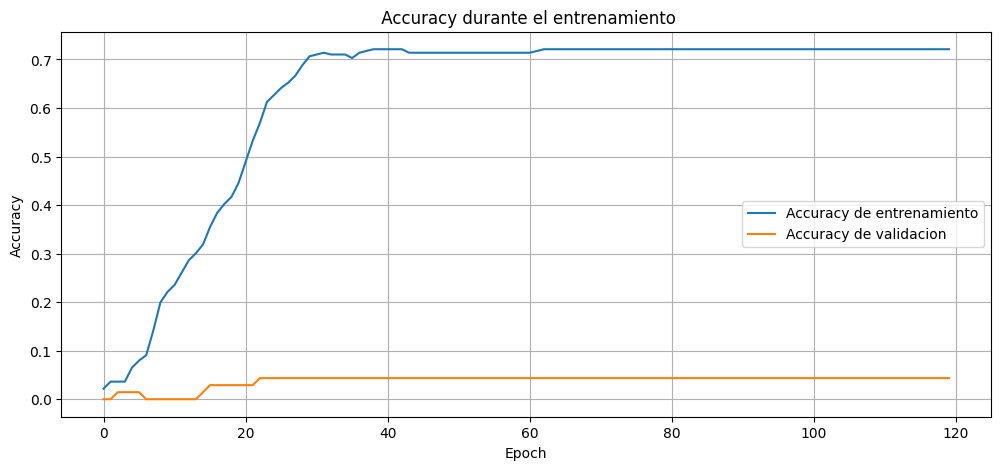

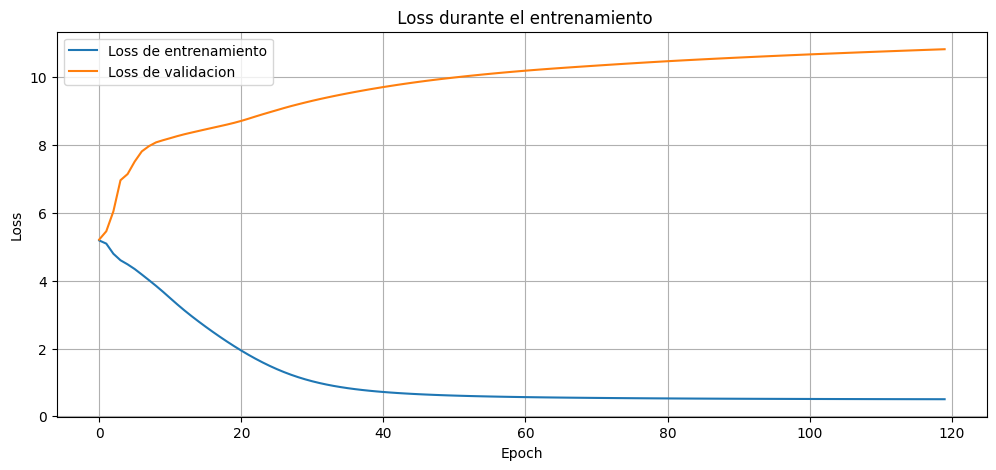

In [8]:
# Curvas de entrenamiento

plt.figure(figsize=(12, 5))
plt.plot(historial.history["accuracy"], label="Accuracy de entrenamiento")
plt.plot(historial.history["val_accuracy"], label="Accuracy de validacion")
plt.title(" Accuracy durante el entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(historial.history["loss"], label="Loss de entrenamiento")
plt.plot(historial.history["val_loss"], label="Loss de validacion")
plt.title(" Loss durante el entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Funcion auxiliar para preparar prompts

def preparar_prompt(seed_text, tokenizer, max_sequence_len):

  token_list = tokenizer.texts_to_sequences([seed_text])[0]

  token_list_padded = pad_sequences(
      [token_list],
      maxlen=max_sequence_len-1,
      padding="pre"
  )
  return token_list_padded

In [10]:
# Greedy search

def generar_greedy (modelo, tokenizer, seed_text, max_sequence_len, n_palabras=10):

  texto_generado = seed_text

  for _ in range(n_palabras):

    entrada = preparar_prompt(texto_generado, tokenizer, max_sequence_len)

    probabilidades = modelo.predict(entrada, verbose=0)[0]

    indice_predicho = np.argmax(probabilidades)

    palabra_predicha = ""

    for palabra, indice in tokenizer.word_index.items():
      if indice == indice_predicho:
        palabra_predicha = palabra
        break
    if palabra_predicha == "":
      break

    texto_generado += " " + palabra_predicha
  return texto_generado

In [11]:
# Muestreo por temperatura

def aplicar_temperatura (probabilidades, temperatura=1.0):
  probabilidades = np.asarray(probabilidades).astype("float64")

  probabilidades = np.log(probabilidades + 1e-8)

  probabilidades = probabilidades/ temperatura

  exp_prob = np.exp(probabilidades)

  probabilidades_ajustadas = exp_prob / np.sum(exp_prob)

  return probabilidades_ajustadas

def generar_temperatura(modelo, tokenizer, seed_text, max_sequence_len, n_palabras=10, temperatura=1.0):
  texto_generado = seed_text

  for _ in range(n_palabras):

    entrada = preparar_prompt(texto_generado, tokenizer, max_sequence_len)

    probabilidades = modelo.predict(entrada, verbose=0)[0]

    probabilidades_ajustadas = aplicar_temperatura(probabilidades, temperatura)

    indice_predicho = np.random.choice(
        len(probabilidades_ajustadas),
        p=probabilidades_ajustadas
    )

    palabra_predicha = ""

    for palabra, indice in tokenizer.word_index.items():
      if indice == indice_predicho:
        palabra_predicha = palabra
        break
    if palabra_predicha == "":
      break

    texto_generado += " " + palabra_predicha
  return texto_generado

In [17]:
# Top k samplig

def filtrar_top_k(probabilidades, k=5):

  probs_filtradas = np.copy(probabilidades)

  indices_ordenados = np.argsort(probs_filtradas)

  inidices_a_eliminar = indices_ordenados[:-k]

  probs_filtradas [inidices_a_eliminar]=0

  probs_filtradas /= np.sum(probs_filtradas)

  return probs_filtradas

def generar_top_k(modelo, tokenizer, seed_text, max_sequence_len, n_palabras=10, k=5):
  texto_generado = seed_text

  for _ in range(n_palabras):

    entrada = preparar_prompt(texto_generado, tokenizer, max_sequence_len)

    probabilidades = modelo.predict(entrada, verbose=0)[0]

    probabilidades_top_k = filtrar_top_k(probabilidades, k=k)

    indice_predicho = np.random.choice(
        len(probabilidades_top_k),
        p=probabilidades_top_k
    )

    palabra_predicha = ""

    for palabra, indice in tokenizer.word_index.items():
      if indice == indice_predicho:
        palabra_predicha = palabra
        break
    if palabra_predicha == "":
      break

    texto_generado += " " + palabra_predicha
  return texto_generado

In [18]:
# Top P

def filtrar_top_p(probabilidades, p=0.9):

  indices_ordenados = np.argsort(probabilidades)[::-1]

  probabilidades_ordenadas = probabilidades[indices_ordenados]

  suma_acumulada = np.cumsum(probabilidades_ordenadas)

  indices_fuera = suma_acumulada > p

  indices_fuera[0]= False

  probs_filtradas = np.copy(probabilidades)

  indices_a_eliminar = indices_ordenados[indices_fuera]

  probs_filtradas[indices_a_eliminar]= 0

  probs_filtradas /= np.sum(probs_filtradas)

  return probs_filtradas

def generar_top_p(modelo, tokenizer, seed_text, max_sequence_len, n_palabras=10, p=0.9):
  texto_generado = seed_text

  for _ in range(n_palabras):

    entrada = preparar_prompt(texto_generado, tokenizer, max_sequence_len)

    probabilidades = modelo.predict(entrada, verbose=0)[0]

    probabilidades_top_p = filtrar_top_p(probabilidades, p=p)

    indice_predicho = np.random.choice(
        len(probabilidades_top_p),
        p=probabilidades_top_p
    )

    palabra_predicha = ""

    for palabra, indice in tokenizer.word_index.items():
      if indice == indice_predicho:
        palabra_predicha = palabra
        break
    if palabra_predicha == "":
      break

    texto_generado += " " + palabra_predicha
  return texto_generado

In [21]:
# Beam search

def generar_beam_search(modelo, tokenizer, seed_text, max_sequence_len,
                        n_palabras=10, beam_width=3):

  # Cada hipotesis es una tupla:
  # (texto, puntaje)
  secuencias = [(seed_text,0.0)]

  for _ in range(n_palabras):

    # Aqui guardamos todas las expansiones candidatas
    candidatos = []

    for texto_actual, puntaje_actual in secuencias:

      # Preparamos la entrada
      entrada = preparar_prompt(texto_actual, tokenizer, max_sequence_len)

      # Obtenemos probabilidades
      probabilidades = modelo.predict(entrada, verbose=0)[0]

      # Tomamos los indices de las palabras más probables
      top_indices = np.argsort(probabilidades)[-beam_width:]

      for indice in top_indices:
        palabra = ""

        for palabra_vocab, indice_vocab in tokenizer.word_index.items():
          if indice_vocab == indice:
            palabra = palabra_vocab
            break
        if palabra == "":
          continue

        nuevo_puntaje = puntaje_actual + np.log(probabilidades[indice]+ 1e-8)

        nuevo_texto = texto_actual + " " + palabra

        candidatos.append((nuevo_texto, nuevo_puntaje))

    # Ordenamos candidatos por puntaje descendiente
    candidatos = sorted(candidatos, key=lambda x: x[1], reverse=True)

    # COnservamos solo las mejores rutas
    secuencias = candidatos[:beam_width]

  return secuencias[0][0]

In [22]:
# Comparacion de estrategias de decodificacion

prompts=[
    "la inteligencia",
    "las redes",
    "la perplejidad",
    "beam search",
    "la generacion"
]

for prompt in prompts:
  print("-"*90)
  print("PROMPT:", prompt)
  print("-"*90)

  print("\nGreedy:")
  print(generar_greedy(modelo_gru, tokenizer, prompt, max_sequence_len, n_palabras=8))

  print("\nTemperatura 0.7:")
  print(generar_temperatura(modelo_gru, tokenizer, prompt,
                            max_sequence_len, n_palabras=8, temperatura=0.7))
  print("\nTemperatura 1.2:")
  print(generar_temperatura(modelo_gru, tokenizer, prompt,
                            max_sequence_len, n_palabras=8, temperatura=1.2))
  print("\nTop k, k=5:")
  print(generar_top_k(modelo_gru, tokenizer, prompt, max_sequence_len, n_palabras=8, k=5))

  print("\nTop-P, p=0.9:")
  print(generar_top_p(modelo_gru, tokenizer, prompt,
                      max_sequence_len, n_palabras=8, p=0.9))

  print("\nBeam search, beam_width=3:")
  print(generar_beam_search(modelo_gru, tokenizer, prompt,
                            max_sequence_len, n_palabras=8, beam_width=3))
  print("\n")

------------------------------------------------------------------------------------------
PROMPT: la inteligencia
------------------------------------------------------------------------------------------

Greedy:
la inteligencia artificial necesita contexto para predecir predecir predecir tokens

Temperatura 0.7:
la inteligencia artificial procesa secuencias de texto paso a paso

Temperatura 1.2:
la inteligencia artificial procesa secuencias de texto conserva muestreo mucha

Top k, k=5:
la inteligencia artificial usa modelos probabilisticos probabilidades palabra siguiente tokens

Top-P, p=0.9:
la inteligencia artificial usa modelos probabilisticos predecir siguiente token siguiente

Beam search, beam_width=3:
la inteligencia artificial aprende patrones en los datos datos vector


------------------------------------------------------------------------------------------
PROMPT: las redes
------------------------------------------------------------------------------------------

Greed